In [1]:
import torch
import torchaudio
import json
import os
import random
from pathlib import Path
from tqdm import tqdm
import sys
from einops import rearrange
import matplotlib.pyplot as plt
import librosa
import librosa.display
import numpy as np

from stable_audio_tools.models.factory import create_model_from_config
from stable_audio_tools.models.utils import load_ckpt_state_dict
from stable_audio_tools.inference.generation import generate_diffusion_cond

# Generation

In [12]:
def generate_samples(model, model_name, samples, class_mappings: str = "class_mapping.json", cfg:float  = 6.0, audio_length:int = 12, sample_rate = 44100, steps = 100, hybrid = True, device = "cuda"):

    with open(class_mappings, "r", encoding="utf-8") as file:
        class_mappings = json.load(file)

    sample_size = int(audio_length * sample_rate)

    base_dir = Path(f"generations/{model_name}")
    base_dir.mkdir(parents=True, exist_ok=True)

    for class_name, mapping in class_mappings.items():
        target_id = mapping["id"]
        target_str = mapping["name"]

        class_dir = base_dir / class_name
        class_dir.mkdir(exist_ok=True)

        if hybrid:
            prompt = f"A field recording of a {target_str} singing in nature, stereo audio."
        else:
            prompt = f"A field recording of a bird singing in nature, stereo audio."

        conditioning = [{
        "prompt": prompt,
        "seconds_start": 0,
        "seconds_total": audio_length,
        "species_id": target_id
        }]

        for sample_idx in tqdm(range(samples), desc=f"Generating {class_name} (ID: {target_id})", unit="sample"):
            dynamic_seed = random.randint(0, 2147483647)
            with torch.no_grad():
                output = generate_diffusion_cond(
                    model,
                    steps=steps,
                    cfg_scale=cfg,
                    conditioning=conditioning,
                    sample_size=sample_size,
                    sigma_min=0.3,
                    sigma_max=500,
                    sampler_type="dpmpp-3m-sde",
                    device=device,
                    seed=dynamic_seed
                )

            file_out = class_dir / f"{class_name}_{sample_idx + 1}.wav"
            output = output.to(torch.float32).div(torch.max(torch.abs(output))).clamp(-1, 1).cpu()
            output = rearrange(output, "b d n -> d (b n)")
            torchaudio.save(file_out, output, sample_rate)
            

In [13]:
CONFIG_PATH = "checkpoints/model_config_hybrid.json"
CKPT_PATH = "runs/hybrid_v1/models/epoch=22-step=6000.ckpt"

with open(CONFIG_PATH, "r") as f:
    model_config = json.load(f)

sample_rate = model_config["sample_rate"]
model = create_model_from_config(model_config)

C:\Users\Leonard Leber\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


In [14]:
raw_state_dict = load_ckpt_state_dict(CKPT_PATH)

clean_state_dict = {}
for key, value in raw_state_dict.items():
    if key.startswith('diffusion_ema.ema_model.'):
        new_key = key.replace('diffusion_ema.ema_model.', '')
        clean_state_dict[new_key] = value

    elif key.startswith('diffusion.'):
        new_key = key.replace('diffusion.', '', 1)
        if new_key not in clean_state_dict:
            clean_state_dict[new_key] = value

model.load_state_dict(clean_state_dict, strict=False)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device, dtype=torch.float16)
model.eval()
print(device)

cuda


In [ ]:
generate_samples(model, "hybrid_6000", 30, "class_mapping_runpod.json")

# Evaluation

In [6]:
# from frechet_audio_distance import FrechetAudioDistance

real_audio_dir = Path("./data_preprocessed_general")
generated_audio_dir =Path("./generations/hybrid_6000")

real_path_str = str(real_audio_dir.absolute())
gen_path_str = str(generated_audio_dir.absolute())

In [ ]:
# sys.executable

In [30]:
def evaluate_quality(real_audio_dir, generated_audio_dir):
    frechet = FrechetAudioDistance(
        model_name="vggish",
        sample_rate=16000,
        use_pca=False,
        use_activation=False,
        verbose=True
    )
    try:
        fad_score = frechet.score(real_audio_dir, generated_audio_dir)
        print(f"\nFINAL FAD SCORE: {fad_score:.4f}")
    except Exception as e:
        print(f"FAD Calculation failed: {e}")

In [ ]:
evaluate_quality(real_path_str, gen_path_str)

In [ ]:
def evaluate_species_accuracy(real_audio_dir, generated_audio_dir):
    pass

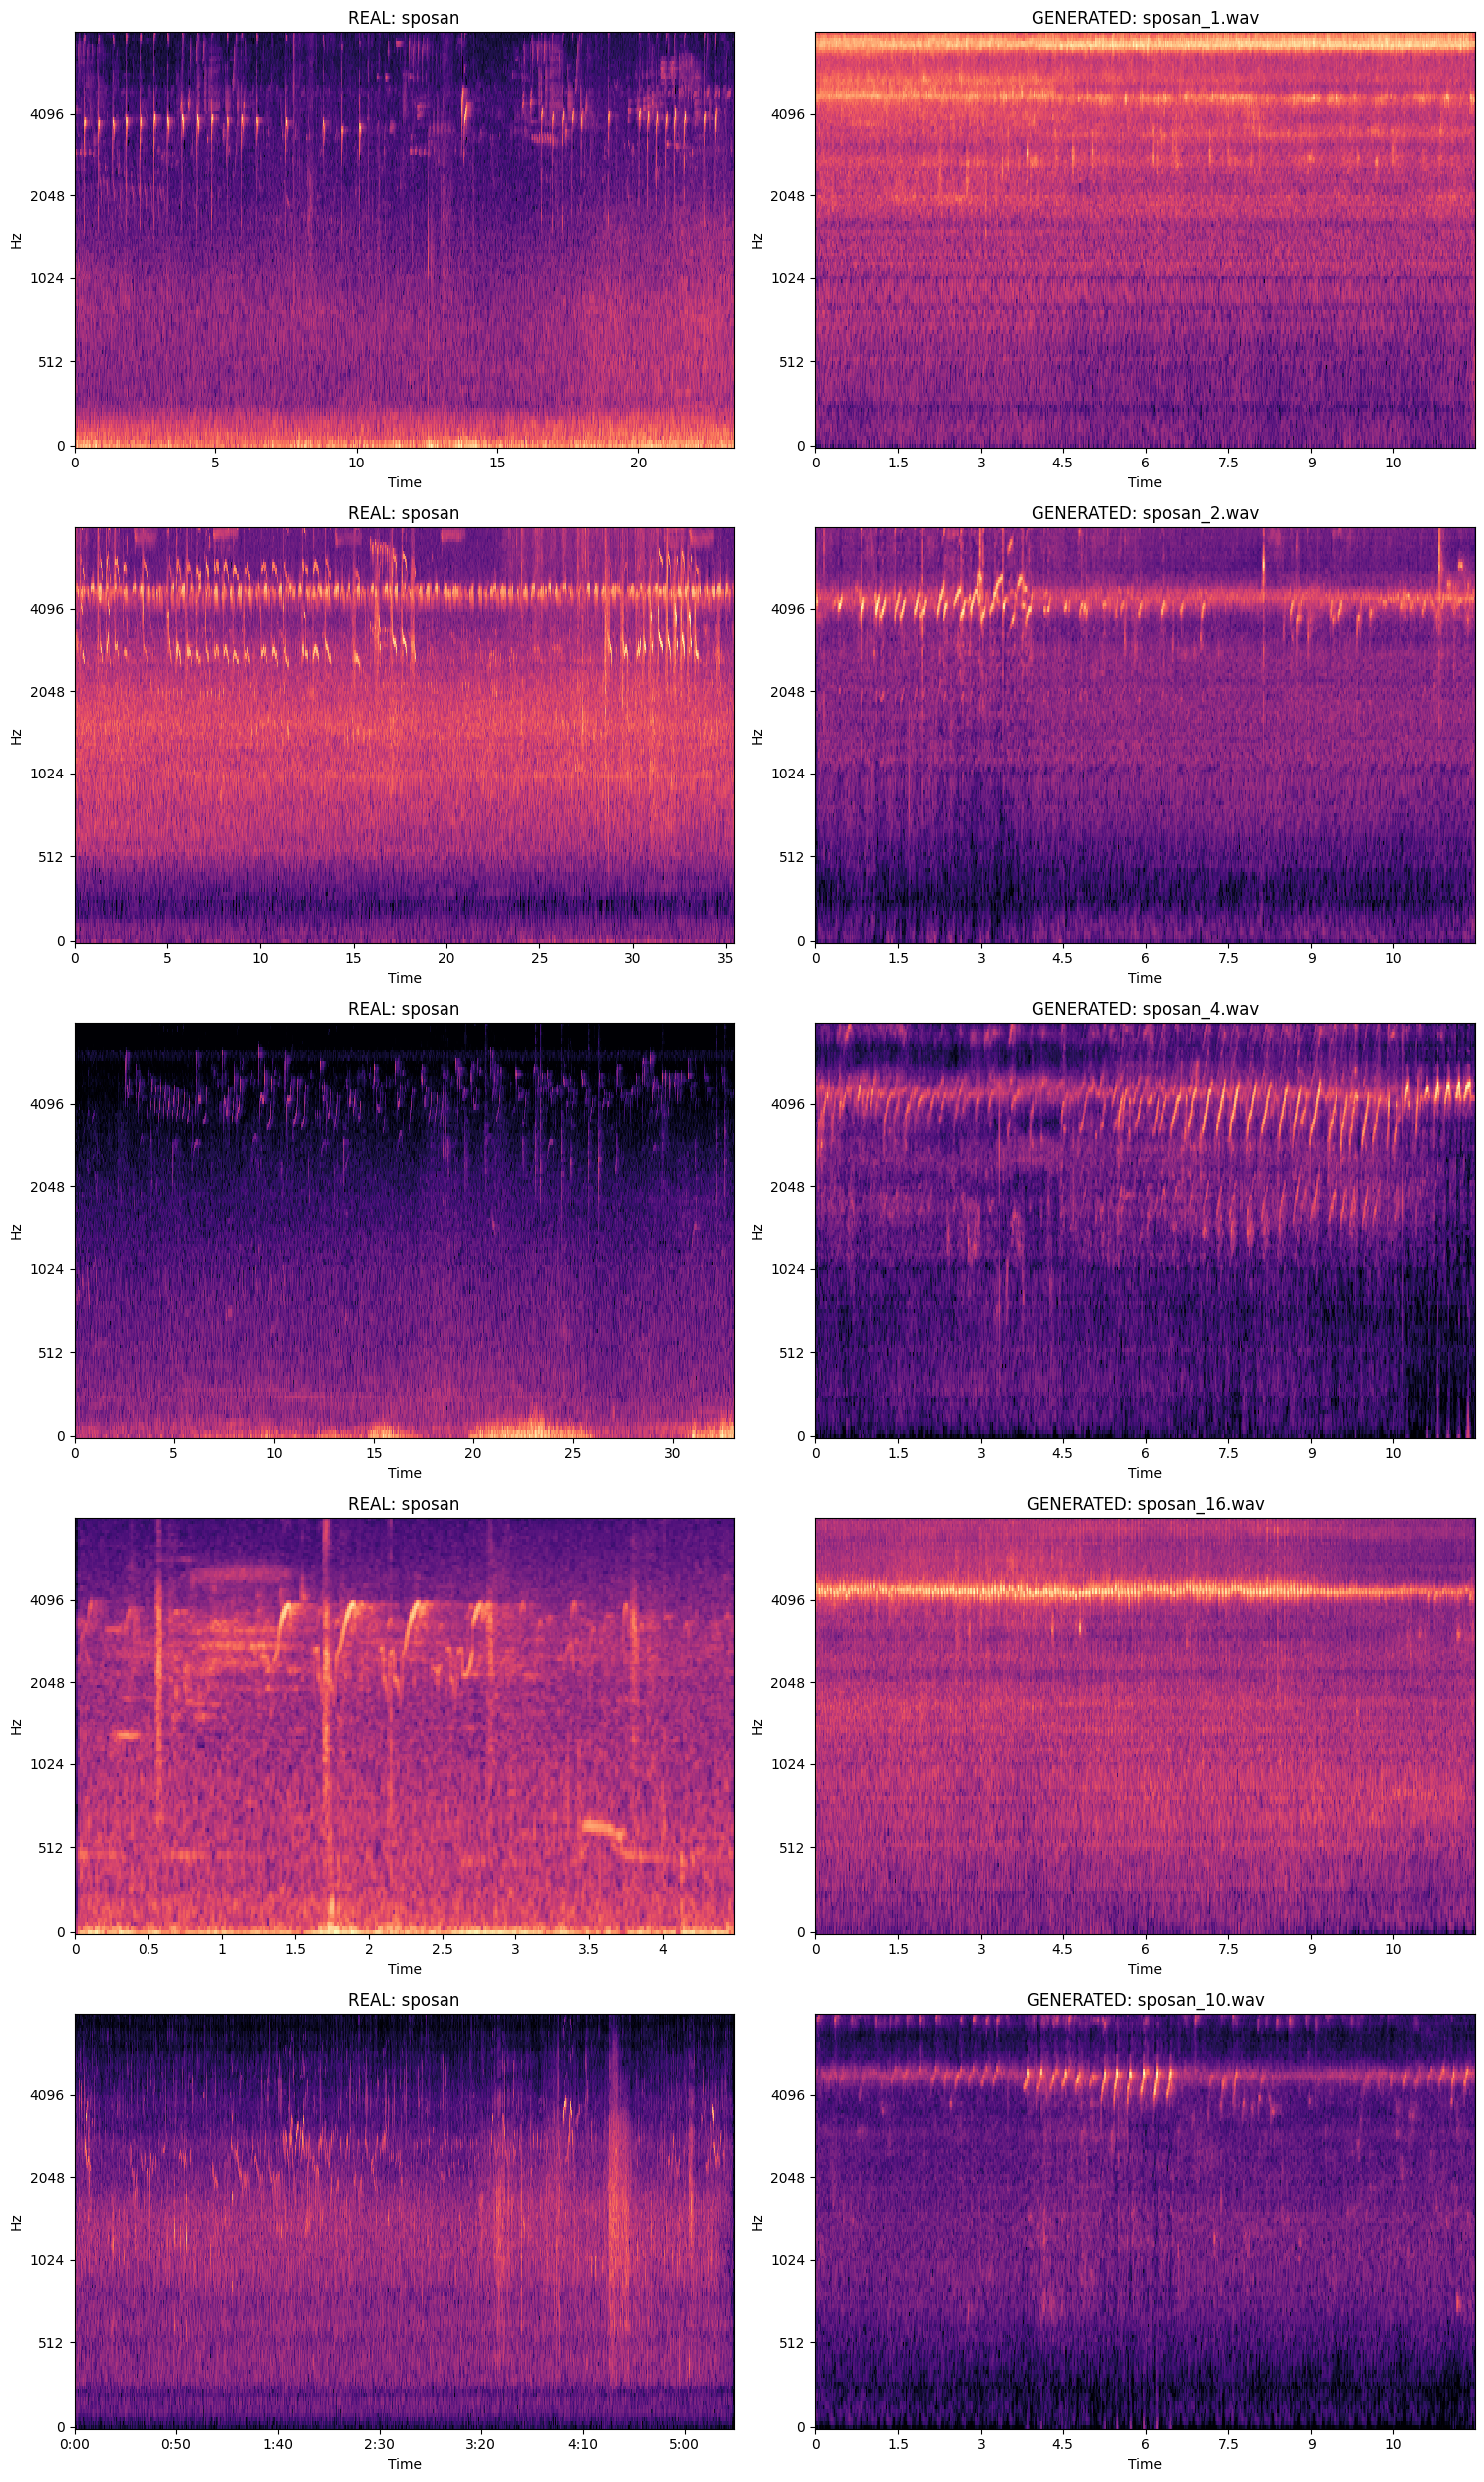

In [14]:
def plot_spectrogram(ax, audio_path, title):
    try:
        y, sr = librosa.load(audio_path, sr=None)
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
        S_dB = librosa.power_to_db(S, ref=np.max)
        
        img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, fmax=8000, ax=ax, cmap='magma')
        ax.set_title(title)
        return img
    except Exception as e:
        print(f"Could not load {audio_path}: {e}")
        return None
    
def show_spectrogram(class_id, nr_samples, real_audio_dir, generated_audio_dir, class_mappings):
    with open(class_mappings, "r", encoding="utf-8") as file:
        class_mappings = json.load(file)
    class_name = next((key for key, val in class_mappings.items() if val["id"] == class_id), None)
    class_name = Path(class_name)

    real_files = list((real_audio_dir / class_name).rglob("*.wav"))
    gen_files = list((generated_audio_dir / class_name) .rglob("*.wav"))
    selected_real = random.sample(real_files, min(nr_samples, len(real_files)))
    selected_gen = random.sample(gen_files, min(nr_samples, len(gen_files)))

    fig, axes = plt.subplots(nrows=nr_samples, ncols=2, figsize=(15, 5 * nr_samples))
    for i in range(nr_samples):
        plot_spectrogram(axes[i, 0], selected_real[i], f"REAL: {class_name}")
        img = plot_spectrogram(axes[i, 1], selected_gen[i], f"GENERATED: {selected_gen[i].name}")
        
   # fig.colorbar(img, ax=axes, format='%+2.0f dB')
    plt.tight_layout()
    plt.show()
show_spectrogram(4, 5, real_audio_dir, generated_audio_dir, "class_mapping_runpod.json")